# 04 - Modelling
**CRISP-DM phase:** Modelling (with one loop back to Data Preparation)

Four models answer the research questions from notebook 01:

| Model | Question | Data | Type |
|---|---|---|---|
| **S1** | Will this crash involve injury? | CRSS crash table | binary classification |
| **S2** | Will this crash involve serious or fatal injury? | CRSS crash table | binary classification, imbalanced (about 13%) |
| **U1** | Which component group(s) is this complaint about? | complaint narratives | multi-label classification (19 groups) |
| **U2** | Does this complaint describe a crash, fire, injury or death? | complaint narratives | binary classification, imbalanced (about 6-10%) |

How this notebook runs:
* **Part A - Benchmark crash models.** Every model family is trained on all 1,456 crash features (303 fields) to choose the model type and set a benchmark.
* **Part B - Back to Data Preparation.** Evaluating the benchmark raised questions about the fields, so the work loops back to *select data*: an ablation test, removal of post-crash fields, and importance-based selection with a 98% rule.
* **Part C - Final crash models.** Gradient Boosting retrained on exactly the selected features: 15 for S1 and 75 for S2, from 50 fields in total. These are the models evaluated in notebook 05 and deployed in notebook 06.
* **Part D - Text models** for U1 and U2.

**Every choice uses the training and validation periods only.** Test results were calculated after the relevant decisions were fixed and were not used to select features, hyperparameters or thresholds; they appear here for completeness and are analysed in notebook 05.

Scripts: `src/train_crss.py` (benchmark), `src/select_crash_features.py` (field selection), `src/train_crss_final.py` (final crash models), `src/train_text.py` (U1, U2). The cells below read the configuration directly from those scripts and show the results they produced.

## 4.0 Setup
`RUN_TRAINING = False` loads saved results. Retraining everything takes about 4 hours on a 12-core laptop with 15 GB RAM (benchmark about 3 hours, field selection about 30 minutes).

In [1]:
from pathlib import Path
import inspect, json, subprocess, sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from project_paths import EVALUATION_DIR, OUTPUT_DIR, TABLE_DIR
import train_crss, select_crash_features, train_crss_final, train_text

SELECTION_DIR = OUTPUT_DIR / "selection"
RUN_TRAINING = False
if RUN_TRAINING:
    for script in ["train_crss.py", "select_crash_features.py", "train_crss_final.py", "train_text.py"]:
        subprocess.run([sys.executable, str(PROJECT_ROOT / "src" / script)], check=True, cwd=PROJECT_ROOT)

pd.set_option("display.max_columns", 40, "display.width", 220, "display.precision", 4)
show_code = lambda obj: display(Markdown("```python\n" + inspect.getsource(obj) + "\n```"))

# Part A - Benchmark crash models (S1, S2)

## 4.1 Preparing the crash table for the models
Two steps convert the crash table into model input, both fitted on the 2020-2022 training years only:
1. **Remove redundant columns:** constant columns and exact duplicates (e.g. pedestrian counts recorded identically in several tables). This takes the 1,456 features to 1,317.
2. **Encode and fill:** the 17 crash-level coded fields are one-hot encoded (giving 1,410 model columns); numeric and count fields have missing values filled with the training median.

Logistic Regression additionally standardises each column (inside its own pipeline); tree models do not need scaling.

In [2]:
show_code(train_crss.drop_redundant)
show_code(train_crss.preprocessor)

```python
def drop_redundant(X: pd.DataFrame) -> list[str]:
    """Remove constant and exactly duplicated columns (decided on training data only).

    Columns are compared by a fingerprint of their values, which avoids transposing the
    whole training matrix (the transpose needed several GB once the VIN-decode fields were added).
    """
    keep, seen = [], set()
    for c in X.columns:
        v = X[c].to_numpy()
        if pd.Series(v).nunique(dropna=False) <= 1:
            continue
        key = hash(np.nan_to_num(v.astype(np.float64), nan=-1e300).tobytes())
        if key not in seen:
            seen.add(key)
            keep.append(c)
    return keep

```

```python
def preprocessor(cat: list[str], num: list[str]) -> ColumnTransformer:
    """Fitted once per feature set on training years; scaling happens inside the LR pipeline."""
    return ColumnTransformer([
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value=-9)),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32))]), cat),
        ("num", MedianImputer32(), num),
    ], verbose_feature_names_out=False)

```

## 4.2 Candidate models and tuning grid
Model families were chosen to move from simple and interpretable to flexible:

| Family | Why it is included |
|---|---|
| Dummy (prior) | No-skill baseline: always predicts the training rate |
| Logistic Regression | Linear, interpretable baseline; tuned on regularisation strength `C` |
| Decision Tree | Readable rules; tuned on depth |
| Random Forest | Many de-correlated trees; tuned on minimum leaf size |
| Gradient Boosting (histogram) | Sequential trees correcting earlier errors; tuned on leaf count, with early stopping |

Selection happens in two steps, both on validation data: within each family, the setting with the best **validation ROC-AUC** is kept; across families, the model with the best **validation PR-AUC** is selected. The decision threshold is the one that maximises F1 on validation data, not a default 0.5.

In [3]:
show_code(train_crss.candidates)

```python
def candidates(balanced: bool) -> dict:
    cw = "balanced" if balanced else None
    lr = lambda c: Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(C=c, max_iter=3000, class_weight=cw))])
    return {
        "Dummy (prior)": [DummyClassifier(strategy="prior")],
        "Logistic Regression": [lr(c) for c in (0.01, 0.1, 1.0)],
        "Decision Tree": [DecisionTreeClassifier(max_depth=d, min_samples_leaf=50, class_weight=cw, random_state=RNG)
                          for d in (6, 10, 14)],
        "Random Forest": [RandomForestClassifier(n_estimators=300, min_samples_leaf=l, max_features="sqrt",
                                                 class_weight=cw, n_jobs=-1, random_state=RNG) for l in (5, 20)],
        "Gradient Boosting": [HistGradientBoostingClassifier(learning_rate=0.08, max_leaf_nodes=n, max_iter=600,
                                                             l2_regularization=1.0, early_stopping=True,
                                                             validation_fraction=0.1, n_iter_no_change=30,
                                                             class_weight=cw, random_state=RNG) for n in (31, 63)],
    }

```

## 4.3 What the benchmark includes
* **All fields.** The benchmark uses every documented field that survived notebook 03 (303 fields from all 28 tables), so nothing is excluded by hand at this stage.
* **A post-crash sensitivity run.** Each family is also trained without the post-crash fields (damage extent, towing, alcohol-test results), to measure how much the models lean on information recorded after the crash. The question it raises is settled in Part B, Step 2.
* **Class weighting (S2 only).** Serious or fatal crashes are about 13% of cases. Each S2 model is also trained with `class_weight="balanced"` to test whether weighting the rare class helps.
* **Small grids on purpose.** The settings tried (shown in 4.2) span weak to strong regularization, so each family gets a fair chance without a long search.
* **No survey weights in training.** The models rank crashes within the CRSS sample, and every record is a real police report, so each is trained on once. The weights describe how many crashes nationally each record stands for; they are used where that matters: national rates (notebook 02) and the weighted ROC-AUC check (notebook 05).

> **Initial plan:** S2 was to predict whether a **vehicle defect** contributed to the crash, linking directly to the complaint data.
> **What we found:** a police-recorded vehicle defect appears for only about 1.6% of vehicles (roughly 1,300-1,700 a year), too few to train a reliable model, and the defect field is recorded after investigation.
> **Decision:** S2 predicts **serious or fatal injury** (about 35,000 positive crashes). Defects remain part of the analysis: notebook 02's tests show crashes with a recorded defect are about 12% more likely to be serious (15.0% vs 13.4%, p = 0.0002).

## 4.4 Results: S1 injury crash (benchmark, all fields)
One row per model family at its best setting. The full comparison file also holds the post-crash sensitivity run.

In [4]:
cols = ["model", "params", "n_input_fields", "fit_seconds", "train_roc_auc", "validation_roc_auc",
        "validation_pr_auc", "test_roc_auc", "test_pr_auc", "selected"]
s1_all = pd.read_csv(EVALUATION_DIR / "crss_y_injury_model_comparison.csv")
s1_all[s1_all.feature_set == "all"][cols]

,model,params,n_input_fields,fit_seconds,train_roc_auc,validation_roc_auc,validation_pr_auc,test_roc_auc,test_pr_auc,selected
0,Dummy (prior),{},1317,0.0,0.5000,0.5000,0.5148,0.5000,0.5130,False
1,Logistic Regression,"{""C"": 0.01}",1317,24.8,0.8915,0.8954,0.9094,0.8860,0.8994,False
2,Decision Tree,"{""max_depth"": 14, ""max_leaf_nodes"": null, ""min...",1317,126.1,0.8926,0.8831,0.8910,0.8837,0.8904,False
3,Random Forest,"{""max_depth"": null, ""max_leaf_nodes"": null, ""m...",1317,168.4,0.9714,0.8980,0.9117,0.8984,0.9112,False
4,Gradient Boosting,"{""max_depth"": null, ""max_leaf_nodes"": 63, ""min...",1317,218.3,0.9278,0.9063,0.9190,0.9063,0.9185,True


**Interpretation.** Every model clearly beats the baseline (validation PR-AUC 0.515). Gradient Boosting has the best validation PR-AUC (0.919) with a small train-validation ROC-AUC gap (0.928 vs 0.906), while Random Forest fits the training years far more closely (0.971) without doing better on validation, a sign of memorising. Gradient Boosting is selected.

## 4.5 Results: S2 serious or fatal crash (benchmark, all fields)

In [5]:
s2_all = pd.read_csv(EVALUATION_DIR / "crss_y_serious_model_comparison.csv")
s2_all[s2_all.feature_set == "all"][["class_weight"] + cols]

,class_weight,model,params,n_input_fields,fit_seconds,train_roc_auc,validation_roc_auc,validation_pr_auc,test_roc_auc,test_pr_auc,selected
0,none,Dummy (prior),{},1317,0.0,0.5000,0.5000,0.1350,0.5000,0.1300,False
1,none,Logistic Regression,"{""C"": 0.01}",1317,21.1,0.8925,0.8668,0.5568,0.8662,0.5438,False
2,none,Decision Tree,"{""max_depth"": 10, ""max_leaf_nodes"": null, ""min...",1317,54.2,0.8730,0.8598,0.5435,0.8612,0.5328,False
3,none,Random Forest,"{""max_depth"": null, ""max_leaf_nodes"": null, ""m...",1317,135.4,0.9830,0.8895,0.6100,0.8899,0.5998,False
4,none,Gradient Boosting,"{""max_depth"": null, ""max_leaf_nodes"": 31, ""min...",1317,128.0,0.9285,0.9000,0.6471,0.9017,0.6421,True
5,balanced,Logistic Regression,"{""C"": 0.01}",1317,24.1,0.8943,0.8656,0.5417,0.8641,0.5258,False
6,balanced,Decision Tree,"{""max_depth"": 10, ""max_leaf_nodes"": null, ""min...",1317,55.9,0.8714,0.8539,0.5163,0.8581,0.5082,False
7,balanced,Random Forest,"{""max_depth"": null, ""max_leaf_nodes"": null, ""m...",1317,116.5,0.9896,0.8885,0.5944,0.8890,0.5851,False
8,balanced,Gradient Boosting,"{""max_depth"": null, ""max_leaf_nodes"": 31, ""min...",1317,99.3,0.9219,0.8992,0.6407,0.9011,0.6343,False


**Interpretation.** PR-AUC is the more informative measure here because only about 13% of crashes are serious; the baseline PR-AUC equals that rate (0.135). Gradient Boosting is again selected (validation PR-AUC 0.647). Class weighting does not help (0.641 vs 0.647), so the unweighted model is kept: weighting shifts the threshold rather than adding information.

**Decision:** Gradient Boosting is the model type for both crash tasks. The next question is whether it needs all 1,410 columns.

# Part B - Back to Data Preparation: selecting the crash fields

## 4.6 Why the loop back
> **Initial plan:** use every documented field from all 28 tables, so that nothing is excluded by hand.
> **What we found:** the benchmark uses 1,410 model columns. That raised three questions. Does every group of fields add information? Are all of them appropriate for a model meant to analyse crash characteristics rather than outcomes? Could a deployed system realistically supply them all?
> **Decision:** follow CRISP-DM's loop back to Data Preparation (task *select data*) and reduce the fields in three documented steps, using the source tags from notebook 03. Every decision uses training and validation data only; the test year only confirms.

The field funnel below accounts for every field, from the 1,114 in the raw tables to the 178 that enter importance-based selection.

In [6]:
pd.read_csv(SELECTION_DIR / "crss_field_funnel.csv").fillna("")

,step,fields,note
0,Raw fields in the 28 CRSS tables (counted per ...,1114,
1,"Excluded by rule: leakage, keys, identifiers, ...",-394,155 distinct field names
2,"Removed as duplicate information: text labels,...",-417,
3,Fields used to build the crash features (bench...,303,"summarised into 1,456 crash features"
4,Removed after the ablation test: VIN-decoded s...,-117,
5,Removed: post-crash fields (recorded after the...,-8,
6,Fields available to importance-based selection,178,


## 4.7 Steps 1 and 2: VIN-decoded fields and post-crash fields
**Step 1 - ablation test.** Gradient Boosting (benchmark settings) is retrained without the 117 VIN-decoded specification fields. **Step 2** then also removes the 8 post-crash fields. The decision column is validation PR-AUC; test PR-AUC is shown only as a later confirmation.

In [7]:
abl = pd.read_csv(SELECTION_DIR / "crss_selection_ablation.csv")
abl = abl.rename(columns={"validation_pr_auc": "validation PR-AUC (decision)", "test_pr_auc": "test PR-AUC (confirmation)"})
abl[["target", "step", "n_features", "n_columns", "validation_roc_auc", "validation PR-AUC (decision)", "test PR-AUC (confirmation)"]]

,target,step,n_features,n_columns,validation_roc_auc,validation PR-AUC (decision),test PR-AUC (confirmation)
0,y_injury,Benchmark: all fields (all 28 tables),1317,1410,0.9063,0.9190,0.9185
1,y_injury,Without VIN-decoded fields,960,1053,0.9067,0.9195,0.9189
2,y_injury,Without VIN-decoded and post-crash fields (sel...,907,1000,0.8986,0.9133,0.9129
3,y_serious,Benchmark: all fields (all 28 tables),1317,1410,0.9000,0.6471,0.6421
4,y_serious,Without VIN-decoded fields,960,1053,0.9004,0.6501,0.6423
5,y_serious,Without VIN-decoded and post-crash fields (sel...,907,1000,0.8918,0.6273,0.6159


**Interpretation and decisions.**
* **Step 1 - VIN-decoded fields removed.** Validation PR-AUC is the same or slightly better without them (S1 0.9190 → 0.9195, S2 0.6471 → 0.6501). What they describe (fitted safety systems, weight, engine) is already carried by model year and body type, and removing them means a deployed system does not need a VIN decoder.
* **Step 2 - post-crash fields removed.** They are recorded after the crash and mostly reflect how bad it was. Removing them costs about 0.01 validation ROC-AUC (S1 PR-AUC 0.9195 → 0.9133, S2 0.6501 → 0.6273), a cost accepted so the models don't lean on consequences of the crash.
* The models still use some information recorded during or just after the crash, such as air-bag deployment, ejection and citations. They are therefore **retrospective analyses of pre-crash, crash-event and investigation information**, not pre-crash predictions.
* What remains (178 fields; 907 features after redundancy removal; 1,000 columns) is the **revised benchmark** for Step 3.

## 4.8 Step 3: importance-based selection with a 98% rule
1. Rank the remaining features by **permutation importance** on validation data: each feature's values are shuffled across 6,000 randomly chosen validation crashes and the drop in validation **ROC-AUC** is recorded (2 repeats, averaged). The features whose shuffling hurts most rank highest.
2. Retrain Gradient Boosting from scratch on the top k features, for k in 5, 10, 15 … 300.
3. Keep the **smallest k whose validation PR-AUC is at least 98% of the revised benchmark's** (S1 0.9133, S2 0.6273), not of the original all-fields model.

The 98% is a business choice: for a decision-support tool that an analyst reviews anyway, giving up at most 2% is worth it for a much simpler data requirement. These top-k models use the benchmark's default settings; the final models are re-tuned in Part C.

Rule: 0.98 | k values tried: [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 300]


**y_injury** (selection run)

,k,n_fields,n_tables,validation_pr_auc,share_of_benchmark_validation_pr_auc,test_pr_auc,share_of_benchmark_test_pr_auc,meets_rule
0,5,3,2,0.8550,0.9362,0.8524,0.9337,False
1,10,8,4,0.8893,0.9737,0.8869,0.9715,False
2,15,13,6,0.8957,0.9808,0.8940,0.9793,True
3,20,16,7,0.8996,0.9850,0.8986,0.9844,True
4,25,19,7,0.9016,0.9872,0.9006,0.9866,True
5,30,21,8,0.9056,0.9916,0.9055,0.9919,True
6,40,28,8,0.9092,0.9955,0.9085,0.9952,True
7,50,35,8,0.9101,0.9965,0.9097,0.9965,True
8,75,46,11,0.9121,0.9988,0.9113,0.9983,True
9,100,59,12,0.9127,0.9994,0.9118,0.9988,True


**y_serious** (selection run)

,k,n_fields,n_tables,validation_pr_auc,share_of_benchmark_validation_pr_auc,test_pr_auc,share_of_benchmark_test_pr_auc,meets_rule
0,5,5,3,0.4150,0.6615,0.4001,0.6495,False
1,10,8,5,0.5073,0.8087,0.4967,0.8064,False
2,15,11,5,0.5463,0.8708,0.5335,0.8662,False
3,20,16,6,0.5724,0.9125,0.5558,0.9024,False
4,25,20,7,0.5849,0.9324,0.5658,0.9186,False
5,30,24,8,0.5973,0.9523,0.5802,0.9420,False
6,40,28,8,0.6061,0.9662,0.5956,0.9670,False
7,50,35,9,0.6119,0.9754,0.6001,0.9743,False
8,75,47,11,0.6187,0.9863,0.6071,0.9857,True
9,100,58,11,0.6216,0.9909,0.6109,0.9919,True


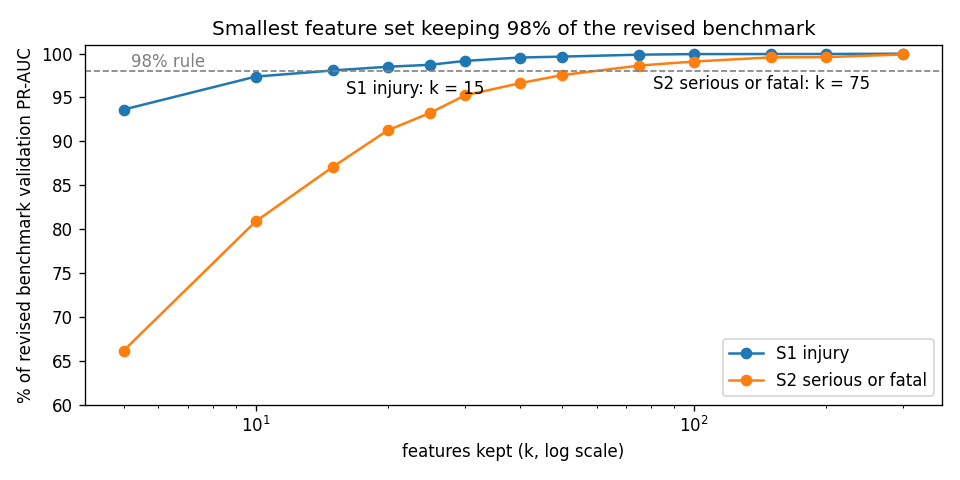

In [8]:
print("Rule:", select_crash_features.RULE, "| k values tried:", select_crash_features.KS)
topk = {t: pd.read_csv(SELECTION_DIR / f"crss_{t}_selection_topk.csv") for t in ("y_injury", "y_serious")}
for t, d in topk.items():
    display(Markdown(f"**{t}** (selection run)"))
    display(d[["k", "n_fields", "n_tables", "validation_pr_auc", "share_of_benchmark_validation_pr_auc",
               "test_pr_auc", "share_of_benchmark_test_pr_auc", "meets_rule"]])

fig, ax = plt.subplots(figsize=(8, 4))
for t, label in [("y_injury", "S1 injury"), ("y_serious", "S2 serious or fatal")]:
    d = topk[t]
    ax.plot(d.k, d.share_of_benchmark_validation_pr_auc * 100, marker="o", label=label)
    k = int(d.loc[d.meets_rule, "k"].min())
    ax.annotate(f"{label}: k = {k}", (k, d.loc[d.k == k, "share_of_benchmark_validation_pr_auc"].iloc[0] * 100),
                textcoords="offset points", xytext=(8, -14))
ax.axhline(98, ls="--", c="grey", lw=1); ax.text(5.2, 98.5, "98% rule", color="grey")
ax.set_xscale("log"); ax.set_ylim(60, 101)
ax.set_xlabel("features kept (k, log scale)"); ax.set_ylabel("% of revised benchmark validation PR-AUC")
ax.set_title("Smallest feature set keeping 98% of the revised benchmark"); ax.legend(); fig.tight_layout()
fig.savefig(SELECTION_DIR / "crss_selection_curve.png", dpi=120); plt.close(fig)
display(Image(SELECTION_DIR / "crss_selection_curve.png"))

**Interpretation.** S1 reaches the rule at **15 features (13 fields)**: 98.1% of the revised benchmark. S2 needs **75 features (47 fields)**: 98.6%. S2 needs more because serious crashes are rare (13%) and depend on more detailed circumstances. Both curves level off well before 100 features, so the remaining features add almost nothing. The test shares (last columns) track the validation shares closely, confirming the choice without having been used to make it.

## 4.9 The fields the final crash models use
The selected features map back to raw CRSS fields. A deployed crash record must supply the union of both models' fields: **50 fields from 12 tables**, down from 303.

In [9]:
sel = json.loads((SELECTION_DIR / "crss_selected_features.json").read_text())
for t in ("y_injury", "y_serious"):
    s = sel[t]
    print(f"{t}: k = {s['k']} features from {len(s['fields'])} fields")
print("\nS1 features:", sel["y_injury"]["features"])
dep = pd.DataFrame([f.split(".") for f in sel["deployment_fields"]], columns=["table", "field"])
dep["S1"] = [f in sel["y_injury"]["fields"] for f in sel["deployment_fields"]]
dep["S2"] = [f in sel["y_serious"]["fields"] for f in sel["deployment_fields"]]
print(f"\nDeployment fields: {len(dep)} from {dep.table.nunique()} tables "
      f"(S1 {dep.S1.sum()}, S2 {dep.S2.sum()}, both {(dep.S1 & dep.S2).sum()})")
dep.groupby("table").agg(fields=("field", ", ".join), n=("field", "size"), S1=("S1", "sum"), S2=("S2", "sum"))

y_injury: k = 15 features from 13 fields
y_serious: k = 75 features from 47 fields

S1 features: ['person__EJECT_IM=8', 'person__AIR_BAG=8', 'person__AIR_BAG=9', 'person__AIR_BAG=1', 'vevent__n_rows', 'person__REST_USE=20', 'vehicle__VNUM_LAN=8', 'acc__REGION', 'vehicle__TRAV_SP__max', 'vehicle__HIT_RUN=1', 'person__PERALCH_IM=1', 'person__SEX_IM=2', 'cevent__SOE=1', 'acc__ALCHL_IM', 'drimpair__DRIMPAIR=0']

Deployment fields: 50 from 12 tables (S1 13, S2 47, both 10)


,fields,n,S1,S2
table,,,,
accident,"ALCHL_IM, EVENT1_IM, HOUR_IM, LGTCON_IM, MANCO...",8,2,7
cevent,"AOI1, AOI2, SOE, n_rows",4,1,4
distract,DRDISTRACT,1,0,1
drimpair,DRIMPAIR,1,1,1
driverrf,DRIVERRF,1,0,1
maneuver,MANEUVER,1,0,1
pbtype,PEDPOS,1,0,1
person,"AGE_IM, AIR_BAG, BODY_TYP, DRUGS, EJECT_IM, GV...",14,5,13
personrf,PERSONRF,1,0,1


**Interpretation.** Several selected features are proxies rather than direct measures, which matters when explaining them:
* `person__EJECT_IM=8` counts people whose ejection is coded "not applicable". Ejection only applies to occupants of enclosed vehicles, and NHTSA also codes it as not applicable for motorcycle, scooter and moped riders, so this counts **people not inside an enclosed vehicle** (pedestrians, cyclists and motorcyclists). Notebook 05 checks who they are.
* Restraint code 20 means "none used / not applicable", so it mixes unrestrained occupants with people for whom restraints don't apply.
* `cevent__SOE=1` (sequence of events) is rollover.

# Part C - Final crash models

## 4.10 Retraining on the selected features
Gradient Boosting is retrained on exactly the selected features with the same split and preprocessing. The tree size (31 or 63 leaves) is re-tuned on validation ROC-AUC and the threshold is set on validation F1; the test year is scored only after these are fixed. The saved bundles (`models/crss_<target>_final.joblib`) are what notebook 05 evaluates and notebook 06 deploys.

**How the settings were chosen.** Only the tree size was tuned (31 or 63 leaves), because it controls how complex each tree can be and so matters most for overfitting. The learning rate (0.08), L2 penalty (1.0), limit of 600 trees and minimum of 20 crashes per leaf are standard values set once and kept fixed for every crash model, from the benchmark to the final models; early stopping (10% of training held out, stop after 30 rounds without improvement) decides how many trees are actually used. Keeping them fixed means the benchmark, the selection runs and the final models differ only in their inputs, so comparing them is fair.

In [10]:
src_run = inspect.getsource(train_crss_final.run)
print(src_run[:src_run.index("rows = []")])
final = pd.concat([pd.read_csv(EVALUATION_DIR / "final" / f"crss_{t}_final_results.csv") for t in ("y_injury", "y_serious")])
bench = {t: abl[(abl.target == t) & abl.step.str.contains("post-crash")]["validation PR-AUC (decision)"].iloc[0]
         for t in ("y_injury", "y_serious")}
final["share_of_revised_benchmark_validation"] = [None if r.model.startswith("Dummy") else r.validation_pr_auc / bench[r.target]
                                                  for r in final.itertuples()]
final[["target", "model", "n_features", "n_fields", "n_columns", "max_leaf_nodes", "threshold", "validation_pr_auc",
       "share_of_revised_benchmark_validation", "test_pr_auc", "test_roc_auc", "test_precision", "test_recall"]]

def run(target: str, df: pd.DataFrame, reg: pd.DataFrame, chosen: dict) -> pd.DataFrame:
    feats = chosen["features"]
    known = df[target] >= 0
    tr, va, te = (df.loc[known & m, feats + [target, "WEIGHT"]] for m in
                  (df.YEAR.isin(CRSS_TRAIN_YEARS), df.YEAR == CRSS_VALIDATION_YEAR, df.YEAR == CRSS_TEST_YEAR))
    cat = [f for f in feats if reg.loc[f, "kind"] == "categorical_code"]
    prep = train_crss.preprocessor(cat, [f for f in feats if f not in cat]).fit(tr[feats])
    Xtr, Xva, Xte = (prep.transform(x[feats]).astype(np.float32, copy=False) for x in (tr, va, te))
    ytr, yva, yte = tr[target].values, va[target].values, te[target].values

    # Re-tune tree size on validation only.
    best = None
    for leaves in (31, 63):
        m = gb({"max_leaf_nodes": leaves, "min_samples_leaf": 20}).fit(Xtr, ytr)
        pv = m.predict_proba(Xva)[:, 1]
        auc = roc_auc_score(yva, pv)
        print(f"  {target} leaves={leaves} validation ROC-AUC {auc:.4f}", flush=

,target,model,n_features,n_fields,n_columns,max_leaf_nodes,threshold,validation_pr_auc,share_of_revised_benchmark_validation,test_pr_auc,test_roc_auc,test_precision,test_recall
0,y_injury,Dummy (prior),15,13,19,NaN,NaN,0.5148,NaN,0.5130,0.5000,NaN,NaN
1,y_injury,Gradient Boosting (final),15,13,19,31.0,0.4053,0.8959,0.9810,0.8943,0.8725,0.8088,0.7827
0,y_serious,Dummy (prior),75,47,126,NaN,NaN,0.1350,NaN,0.1300,0.5000,NaN,NaN
1,y_serious,Gradient Boosting (final),75,47,126,63.0,0.2520,0.6202,0.9887,0.6100,0.8890,0.5041,0.6292


**Interpretation.** S1 keeps the same tree size as in the selection run, so its validation PR-AUC stays at 0.896 (98.1% of the revised benchmark). S2 moves to a larger tree (63 leaves), which raises its validation PR-AUC from 0.619 in the selection run to 0.620 (98.9%); both versions pass the rule, and the 98.6% in 4.8 is the selection-run figure. On the 2024 test year S1 scores PR-AUC 0.894 (baseline 0.513) and S2 0.610 (baseline 0.130). Against the original all-fields models, they keep 97.4% (S1) and 95.0% (S2) of test PR-AUC while needing about one-sixth of the fields. Notebook 05 checks these final models for overfitting, stability, calibration and what drives them.

# Part D - Text models (U1, U2)

## 4.11 Turning narratives into features: TF-IDF
Each narrative becomes a vector of **TF-IDF** weights over words and two-word phrases (e.g. "air bags", "lost power"):
* **TF** (term frequency): how often a term appears in this complaint (log-scaled, so repetition counts less).
* **IDF** (inverse document frequency): terms that appear in many complaints, such as "vehicle", get less weight.

Settings: unigrams and bigrams, terms in at least 5 complaints and at most half of them, 300,000 terms at most. Why: word pairs capture phrases single words miss ("air bag", "lost power"); terms in fewer than 5 complaints are mostly typos and one-off words that can't generalize; terms in more than half of all complaints, such as "vehicle", don't help tell groups apart; the 300,000-term cap keeps the model within the laptop's memory. The vocabulary is **fitted on the 741,623 training complaints only**.

In [11]:
src = inspect.getsource(train_text.main)
print(src[src.index("vec = TfidfVectorizer"):src.index("Xtr = vec.fit_transform")])

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.5, max_features=300000, sublinear_tf=True,
                          lowercase=True, strip_accents="unicode", token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9]+\b",
                          dtype=np.float32)
    


## 4.12 Candidate text models
| Family | Why it is included |
|---|---|
| Dummy (prior) | No-skill baseline |
| Complement Naive Bayes | Fast probabilistic model suited to word counts and imbalanced classes |
| Logistic Regression | Linear model; coefficients show which terms push a prediction |
| Linear SVM | Linear maximum-margin classifier; strong standard for high-dimensional text |

U1 is multi-label, so each family is wrapped in **one-vs-rest**: one binary model per component group, each with its own validated threshold. If no group passes its threshold, the highest-scoring group is still recommended, so every complaint receives a routing suggestion.

In [12]:
show_code(train_text.candidates)

```python
def candidates(task: str) -> dict:
    wrap = (lambda m: OneVsRestClassifier(m, n_jobs=4)) if task == "U1" else (lambda m: m)
    return {
        "Dummy (prior)": [wrap(DummyClassifier(strategy="prior"))],
        "Complement Naive Bayes": [wrap(ComplementNB(alpha=a)) for a in (0.1, 0.5)],
        "Logistic Regression": [wrap(LogisticRegression(C=c, solver="liblinear", max_iter=1000)) for c in (1.0, 4.0)],
        "Linear SVM": [wrap(LinearSVC(C=c)) for c in (0.1, 0.5)],
    }

```

## 4.13 Results: U2 serious-incident flag

In [13]:
u2 = pd.read_csv(EVALUATION_DIR / "text_U2_model_comparison.csv")
u2.drop(columns=["params"])

,task,model,fit_seconds,validation_pr_auc,train_roc_auc,train_pr_auc,train_precision,train_recall,train_f1,validation_roc_auc,validation_precision,validation_recall,validation_f1,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,overfit_gap_train_minus_val,selected
0,U2,Dummy (prior),0.0,0.0639,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,U2,Complement Naive Bayes,1.1,0.8000,0.9543,0.8527,0.8814,0.7199,0.7925,0.9392,0.8286,0.6913,0.7537,0.9453,0.7976,0.8099,0.6962,0.7487,0.0527,False
2,U2,Logistic Regression,52.2,0.8643,0.9947,0.9659,0.9656,0.8214,0.8877,0.9657,0.8759,0.7489,0.8075,0.9661,0.8550,0.8529,0.7469,0.7964,0.1016,False
3,U2,Linear SVM,31.8,0.8670,0.9895,0.9434,0.9368,0.8150,0.8717,0.9647,0.8579,0.7697,0.8114,0.9650,0.8580,0.8342,0.7699,0.8008,0.0764,True


**Interpretation.** The baseline PR-AUC is about 0.06 (the validation positive rate). Linear SVM has the best validation PR-AUC and is selected; Logistic Regression is very close. Naive Bayes trails both but is far above the baseline.

## 4.14 Results: U1 component routing

In [14]:
u1 = pd.read_csv(EVALUATION_DIR / "text_U1_model_comparison.csv")
u1[["model", "fit_seconds", "train_macro_f1", "validation_micro_f1", "validation_macro_f1",
    "validation_top1_accuracy", "test_micro_f1", "test_macro_f1", "test_top1_accuracy", "selected"]]

,model,fit_seconds,train_macro_f1,validation_micro_f1,validation_macro_f1,validation_top1_accuracy,test_micro_f1,test_macro_f1,test_top1_accuracy,selected
0,Dummy (prior),4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,Complement Naive Bayes,16.9,0.6949,0.6608,0.6175,0.7253,0.6436,0.5792,0.7196,False
2,Logistic Regression,583.6,0.8314,0.7304,0.7076,0.8259,0.7256,0.6763,0.8330,False
3,Linear SVM,390.6,0.7864,0.7443,0.7205,0.8360,0.7396,0.6911,0.8441,True


**Interpretation.** *Top-1 accuracy* is the share of complaints whose highest-ranked group is one of their true groups; *macro-F1* averages all 19 groups equally, so small groups count as much as large ones. Linear SVM is selected on validation macro-F1. Logistic Regression fits the training data more closely but generalises slightly worse (a larger train-validation gap; see notebook 05).

**Hand-off.** Notebook 05 evaluates the final crash models (S1, S2) and the selected text models (U1, U2) on the untouched test periods, checks for overfitting, compares the final crash models with the benchmark, and explains what drives their predictions.